In [ ]:
#1 — Import & Konfigurasi
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models
import joblib

# ======= CONFIG =======
TXT_PATH = 'household_power_consumption.txt'  # nama file asli UCI (delimiter ;)
TARGET_COL = 'Global_active_power'            # target (kW)
RESAMPLE_RULE = '1H'                          # resampling per jam (mean)
TEST_SIZE_RATIO = 0.15                        # 15% terakhir -> test
VAL_SIZE_RATIO  = 0.15                        # 15% sebelum test -> val
RANDOM_STATE = 42
LSTM_WINDOW = 24                              # 24 jam ke belakang untuk prediksi 1 jam ke depan

ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)


In [ ]:
#2 — Fungsi Utility (Load TXT, Preprocess, Fitur)
def load_uci_txt(txt_path: str) -> pd.DataFrame:
    """
    Membaca household_power_consumption.txt (UCI):
    - delimiter ';'
    - Date (dd/mm/yyyy) + Time (hh:mm:ss)
    - missing values = '?'
    """
    p = Path(txt_path)
    if not p.exists():
        raise FileNotFoundError(f"Tidak menemukan file: {txt_path}. Upload dulu ke Colab.")

    # Baca cepat tanpa parse datetime dulu
    df = pd.read_csv(
        txt_path,
        sep=';',
        na_values=['?', 'NA', 'NaN', ''],
        low_memory=False
    )
    # Normalisasi nama kolom
    df.columns = [c.strip() for c in df.columns]

    # Pastikan kolom tanggal & waktu ada
    if 'Date' not in df.columns or 'Time' not in df.columns:
        raise KeyError("File tidak memiliki kolom 'Date' dan/atau 'Time'.")

    # Parse datetime (dayfirst=True sesuai format UCI)
    dt = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce', dayfirst=True)
    df = df.assign(datetime=dt).dropna(subset=['datetime']).drop(columns=['Date','Time'])
    df = df.drop_duplicates(subset=['datetime']).sort_values('datetime').set_index('datetime')

    # Konversi numerik semua kolom metrik
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def resample_hourly(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate mean per jam untuk menstabilkan noise & percepat training."""
    return df.resample(RESAMPLE_RULE).mean(numeric_only=True)

def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    idx = out.index
    out['hour'] = idx.hour
    out['dayofweek'] = idx.dayofweek
    out['is_weekend'] = (out['dayofweek'] >= 5).astype(int)
    out['month'] = idx.month
    return out

def add_lag_rolling_features(df: pd.DataFrame, target: str,
                             lags=(1,2,3,6,12,24),
                             roll_windows=(3,6,12,24)) -> pd.DataFrame:
    out = df.copy()
    for lag in lags:
        out[f'{target}_lag{lag}'] = out[target].shift(lag)
    for w in roll_windows:
        out[f'{target}_rollmean{w}'] = out[target].rolling(w).mean()
        out[f'{target}_rollstd{w}']  = out[target].rolling(w).std()
    return out.dropna()

def time_based_split(df: pd.DataFrame, test_ratio=0.15, val_ratio=0.15):
    n = len(df)
    n_test = int(n * test_ratio)
    n_val  = int(n * val_ratio)
    n_train = n - n_test - n_val
    if n_train <= 0:
        raise ValueError("Dataset terlalu kecil setelah resampling/feature engineering.")
    train = df.iloc[:n_train]
    val   = df.iloc[n_train:n_train+n_val]
    test  = df.iloc[n_train+n_val:]
    return train, val, test

def build_xy(df: pd.DataFrame, target: str):
    X = df.drop(columns=[target])
    y = df[target]
    return X, y


In [ ]:
#3 — Load TXT & Resampling per Jam
print("Loading UCI TXT...")
df_raw = load_uci_txt(TXT_PATH)

print("Resampling (1h mean)...")
df_hour = resample_hourly(df_raw).dropna(subset=[TARGET_COL])

display(df_hour.head())
print("Jumlah baris hourly:", len(df_hour))


Loading UCI TXT...
Resampling (1h mean)...


/tmp/ipykernel_2724/1032741718.py:39: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return df.resample(RESAMPLE_RULE).mean(numeric_only=True)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


Jumlah baris hourly: 34168


In [ ]:
#4 — Feature Engineering untuk Model Tree (RF/GB) + Split
print("Menambah fitur kalender + lag/rolling...")
df_feat = add_calendar_features(df_hour)
df_tree = add_lag_rolling_features(df_feat, TARGET_COL)

train_tree, val_tree, test_tree = time_based_split(df_tree, TEST_SIZE_RATIO, VAL_SIZE_RATIO)
X_train_tree, y_train_tree = build_xy(train_tree, TARGET_COL)
X_val_tree,   y_val_tree   = build_xy(val_tree, TARGET_COL)
X_test_tree,  y_test_tree  = build_xy(test_tree, TARGET_COL)

X_train_tree.shape, X_val_tree.shape, X_test_tree.shape


Menambah fitur kalender + lag/rolling...


((23902, 24), (5121, 24), (5121, 24))

In [ ]:
#5 — Train RandomForest & GradientBoosting
print("Training RandomForest...")
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_tree, y_train_tree)
rf_val_pred  = pd.Series(rf.predict(X_val_tree),  index=val_tree.index)
rf_test_pred = pd.Series(rf.predict(X_test_tree), index=test_tree.index)

print("Training GradientBoosting...")
gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    random_state=RANDOM_STATE
)
gb.fit(X_train_tree, y_train_tree)
gb_val_pred  = pd.Series(gb.predict(X_val_tree),  index=val_tree.index)
gb_test_pred = pd.Series(gb.predict(X_test_tree), index=test_tree.index)


Training RandomForest...
Training GradientBoosting...


In [ ]:
#6 — Pipeline LSTM (Scaling Target, Windowing, Training)
def make_supervised_sequence(series: np.ndarray, window: int):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i])
        y.append(series[i])
    return np.array(X), np.array(y)

print("Menyiapkan data LSTM...")
series = df_hour[[TARGET_COL]].dropna().copy()
scaler_y = StandardScaler()
series[TARGET_COL] = scaler_y.fit_transform(series[[TARGET_COL]])

train_lstm, val_lstm, test_lstm = time_based_split(series, TEST_SIZE_RATIO, VAL_SIZE_RATIO)

X_train_l, y_train_l = make_supervised_sequence(train_lstm[TARGET_COL].values, LSTM_WINDOW)
X_val_l,   y_val_l   = make_supervised_sequence(pd.concat([train_lstm.tail(LSTM_WINDOW), val_lstm])[TARGET_COL].values, LSTM_WINDOW)
X_test_l,  y_test_l  = make_supervised_sequence(pd.concat([train_lstm.tail(LSTM_WINDOW), val_lstm, test_lstm])[TARGET_COL].values, LSTM_WINDOW)

X_train_l = X_train_l[..., np.newaxis]
X_val_l   = X_val_l[..., np.newaxis]
X_test_l  = X_test_l[..., np.newaxis]

print("Training LSTM...")
model = models.Sequential([
    layers.Input(shape=(LSTM_WINDOW, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
es = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')

history = model.fit(
    X_train_l, y_train_l,
    validation_data=(X_val_l, y_val_l),
    epochs=100,
    batch_size=64,
    callbacks=[es],
    verbose=1
)


Menyiapkan data LSTM...
Training LSTM...
Epoch 1/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.6103 - val_loss: 0.4745
Epoch 2/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.4724 - val_loss: 0.4404
Epoch 3/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.4551 - val_loss: 0.4302
Epoch 4/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.4492 - val_loss: 0.4508
Epoch 5/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.4472 - val_loss: 0.4202
Epoch 6/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.4428 - val_loss: 0.4246
Epoch 7/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.4423 - val_loss: 0.4183
Epoch 8/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.4405 - val_loss: 0.4182
Epoch 9/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.4391 - val_loss: 0.4122
Epoch 10/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.4373 - val_loss: 0.4256
Epoch 11/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.4372 - va

In [ ]:
#7 — Prediksi LSTM (Inverse Transform + Index Sinkron)
# Prediksi dalam skala terstandar
lstm_val_pred_scaled  = model.predict(X_val_l).ravel()
lstm_test_pred_scaled = model.predict(X_test_l).ravel()

# Balikkan ke skala asli (kW)
lstm_val_pred  = scaler_y.inverse_transform(lstm_val_pred_scaled.reshape(-1,1)).ravel()
lstm_test_pred = scaler_y.inverse_transform(lstm_test_pred_scaled.reshape(-1,1)).ravel()

# Bangun index waktu untuk val/test prediksi LSTM
concat_idx = pd.concat([train_lstm.tail(LSTM_WINDOW), val_lstm, test_lstm]).index
full_idx   = concat_idx[LSTM_WINDOW:]
len_val_target  = len(val_lstm)
len_test_target = len(test_lstm)
val_idx_for_pred  = full_idx[:len_val_target]
test_idx_for_pred = full_idx[len_val_target:len_val_target+len_test_target]

lstm_val_pred_series  = pd.Series(lstm_val_pred[-len(val_idx_for_pred):],  index=val_idx_for_pred)
lstm_test_pred_series = pd.Series(lstm_test_pred[-len(test_idx_for_pred):], index=test_idx_for_pred)


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
#8 — Evaluasi (MAE, RMSE, R²) + Tabel Perbandingan
def regression_report(y_true: np.ndarray, y_pred: np.ndarray):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(np.mean((y_true - y_pred)**2))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Tree-based
rf_mae, rf_rmse, rf_r2 = regression_report(y_test_tree.values, rf_test_pred.values)
gb_mae, gb_rmse, gb_r2 = regression_report(y_test_tree.values, gb_test_pred.values)

# LSTM (ambil target asli)
y_test_lstm_true = df_hour.loc[lstm_test_pred_series.index, TARGET_COL].values
lstm_mae, lstm_rmse, lstm_r2 = regression_report(y_test_lstm_true, lstm_test_pred_series.values)

metrics_df = pd.DataFrame({
    'model': ['RandomForest', 'GradientBoosting', 'LSTM'],
    'MAE':   [rf_mae, gb_mae, lstm_mae],
    'RMSE':  [rf_rmse, gb_rmse, lstm_rmse],
    'R2':    [rf_r2, gb_r2, lstm_r2]
})
display(metrics_df)

best_model = metrics_df.iloc[metrics_df['RMSE'].argmin()]['model']
print(f"Model terbaik menurut RMSE: {best_model}")


,model,MAE,RMSE,R2
0,RandomForest,0.013393,0.022120,0.999029
1,GradientBoosting,0.012642,0.020607,0.999157
2,LSTM,0.341128,0.486282,0.530742


Model terbaik menurut RMSE: GradientBoosting


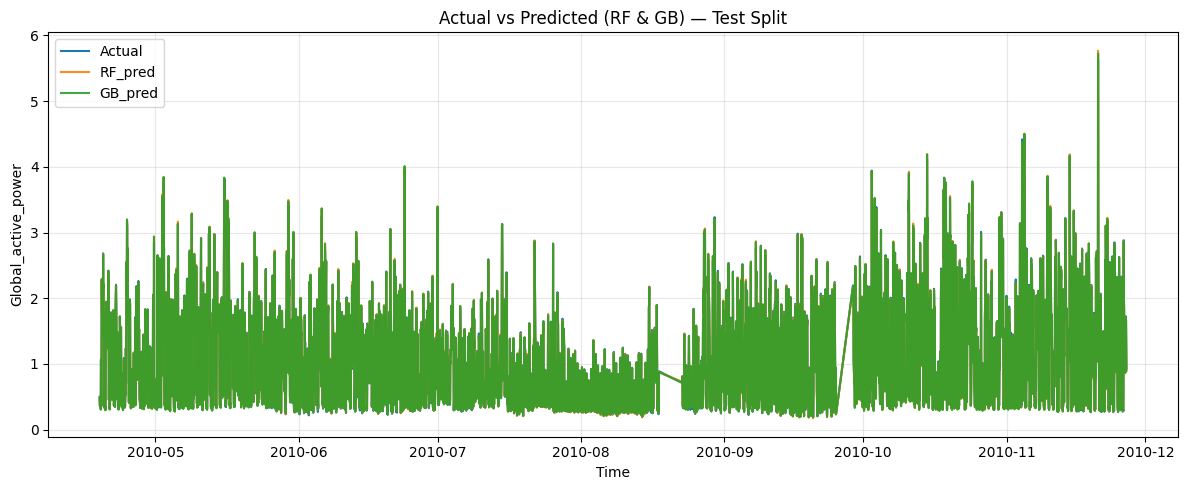

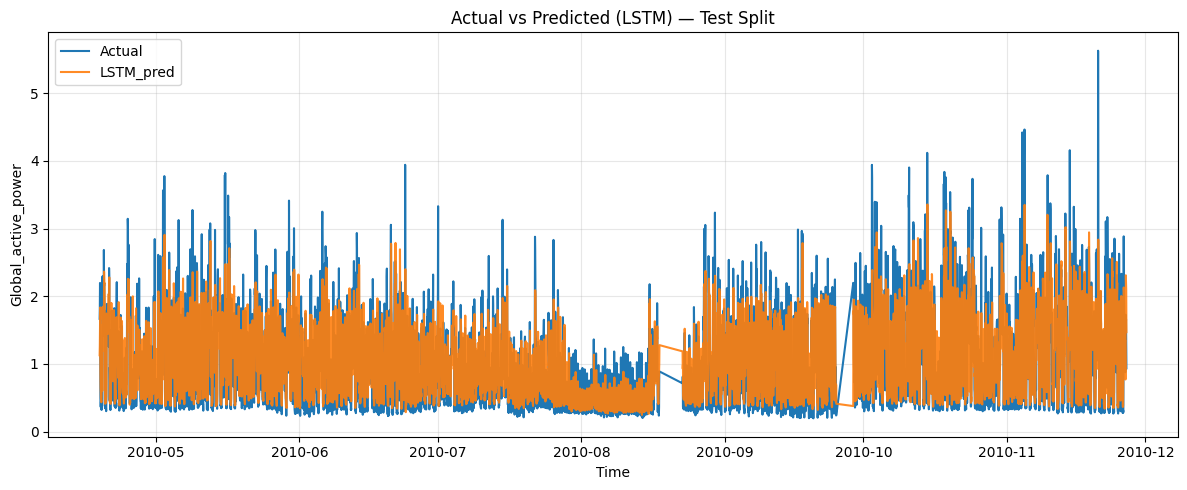

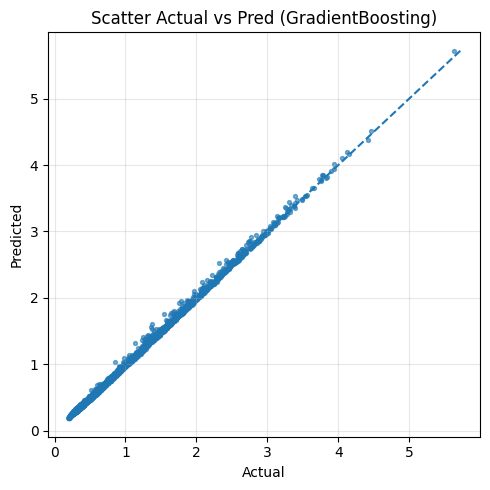

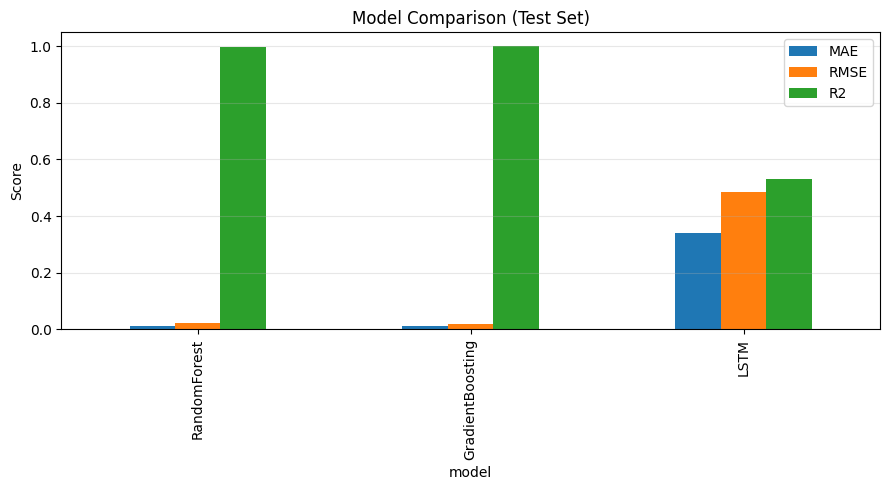

In [ ]:
#9 — Visualisasi (Time Series, Scatter, Bar Chart)
def plot_timeseries(actual: pd.Series, pred_dict: dict, title: str, start=None, end=None):
    plt.figure(figsize=(12,5))
    actual_plot = actual.loc[start:end] if (start or end) else actual
    plt.plot(actual_plot.index, actual_plot.values, label='Actual', linewidth=1.5)
    for name, s in pred_dict.items():
        s_plot = s.loc[start:end] if (start or end) else s
        plt.plot(s_plot.index, s_plot.values, label=name, alpha=0.9)
    plt.title(title); plt.xlabel('Time'); plt.ylabel(TARGET_COL)
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

def plot_scatter_actual_pred(y_true: np.ndarray, y_pred: np.ndarray, title: str):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, s=8, alpha=0.6)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, '--')
    plt.title(title); plt.xlabel('Actual'); plt.ylabel('Predicted')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

def plot_bar_metrics(metrics_df: pd.DataFrame, title: str):
    ax = metrics_df.set_index('model')[['MAE','RMSE','R2']].plot(kind='bar', figsize=(9,5))
    plt.title(title); plt.ylabel('Score'); plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

# 1) RF & GB vs Actual pada split test
plot_timeseries(
    test_tree[TARGET_COL],
    {'RF_pred': rf_test_pred, 'GB_pred': gb_test_pred},
    title='Actual vs Predicted (RF & GB) — Test Split',
    start=test_tree.index.min(), end=test_tree.index.max()
)

# 2) LSTM vs Actual pada split test
plot_timeseries(
    df_hour[TARGET_COL],
    {'LSTM_pred': lstm_test_pred_series},
    title='Actual vs Predicted (LSTM) — Test Split',
    start=lstm_test_pred_series.index.min(),
    end=lstm_test_pred_series.index.max()
)

# 3) Scatter untuk model terbaik
if best_model == 'RandomForest':
    plot_scatter_actual_pred(y_test_tree.values, rf_test_pred.values, 'Scatter Actual vs Pred (RandomForest)')
elif best_model == 'GradientBoosting':
    plot_scatter_actual_pred(y_test_tree.values, gb_test_pred.values, 'Scatter Actual vs Pred (GradientBoosting)')
else:
    plot_scatter_actual_pred(y_test_lstm_true, lstm_test_pred_series.values, 'Scatter Actual vs Pred (LSTM)')

# 4) Bar chart metrik
plot_bar_metrics(metrics_df, 'Model Comparison (Test Set)')


In [ ]:
#10 — Simpan Model & Metrik (Artifacts)
ARTIFACT_DIR.mkdir(exist_ok=True, parents=True)
joblib.dump(rf, ARTIFACT_DIR / 'random_forest_regressor.joblib')
joblib.dump(gb, ARTIFACT_DIR / 'gradient_boosting_regressor.joblib')
model.save(ARTIFACT_DIR / 'lstm_model.keras')
metrics_df.to_csv(ARTIFACT_DIR / 'test_metrics.csv', index=False)

print(f"Artifacts saved in: {ARTIFACT_DIR.resolve()}")
list(ARTIFACT_DIR.iterdir())


Artifacts saved in: /content/artifacts


[PosixPath('artifacts/lstm_model.keras'),
 PosixPath('artifacts/gradient_boosting_regressor.joblib'),
 PosixPath('artifacts/test_metrics.csv'),
 PosixPath('artifacts/random_forest_regressor.joblib')]

In [ ]:
#11 (Opsional) — Prediksi 1-Jam-Ke-Depan (Tree-Based)
def predict_next_hour_tree(latest_hourly_df: pd.DataFrame, model, target: str = TARGET_COL):
    """
    latest_hourly_df: dataframe hourly terbaru (index datetime) berisi kolom target.
    Sediakan minimal 24 jam terakhir agar fitur lag/rolling terbentuk.
    """
    tmp = add_calendar_features(latest_hourly_df)
    tmp = add_lag_rolling_features(tmp, target)
    X_last = tmp.drop(columns=[target]).iloc[[-1]]
    return float(model.predict(X_last)[0])

# contoh:
# next_pred = predict_next_hour_tree(df_hour.copy(), rf)
# print("Prediksi konsumsi (kW) untuk 1 jam ke depan (RF):", next_pred)


,RF_importance,GB_importance
Global_intensity,0.999186,9.992121e-01
Voltage,0.000233,1.704807e-04
Global_reactive_power,0.000206,1.282212e-04
Sub_metering_3,0.000078,2.113053e-04
Sub_metering_2,0.000025,6.222923e-06
Global_active_power_lag24,0.000020,7.249023e-06
Global_active_power_rollstd3,0.000019,1.644190e-06
Global_active_power_rollmean24,0.000019,2.756484e-05
Global_active_power_lag12,0.000019,8.502421e-07
Global_active_power_lag6,0.000017,1.524873e-07


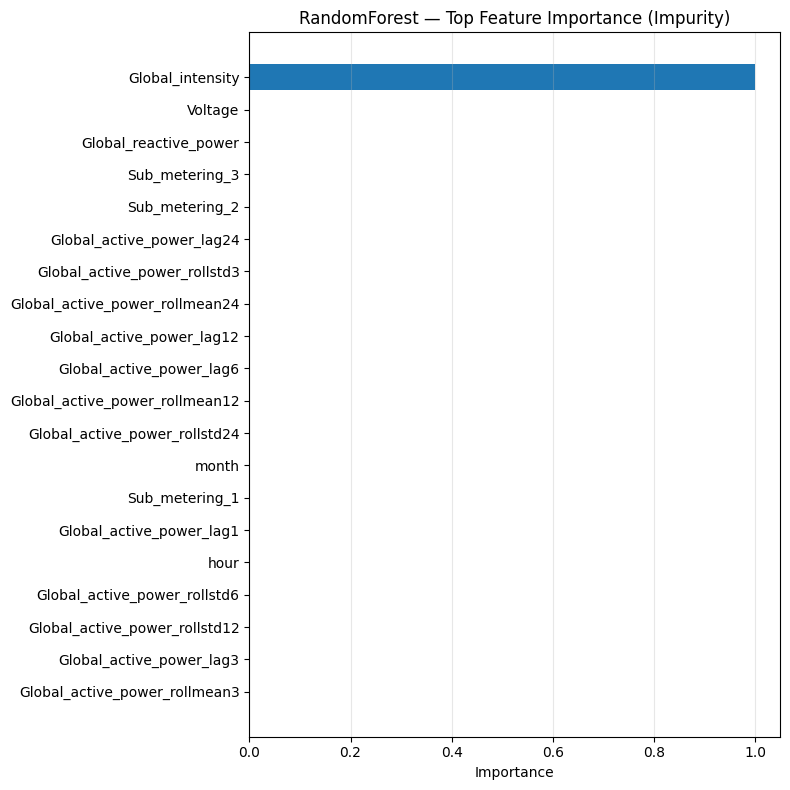

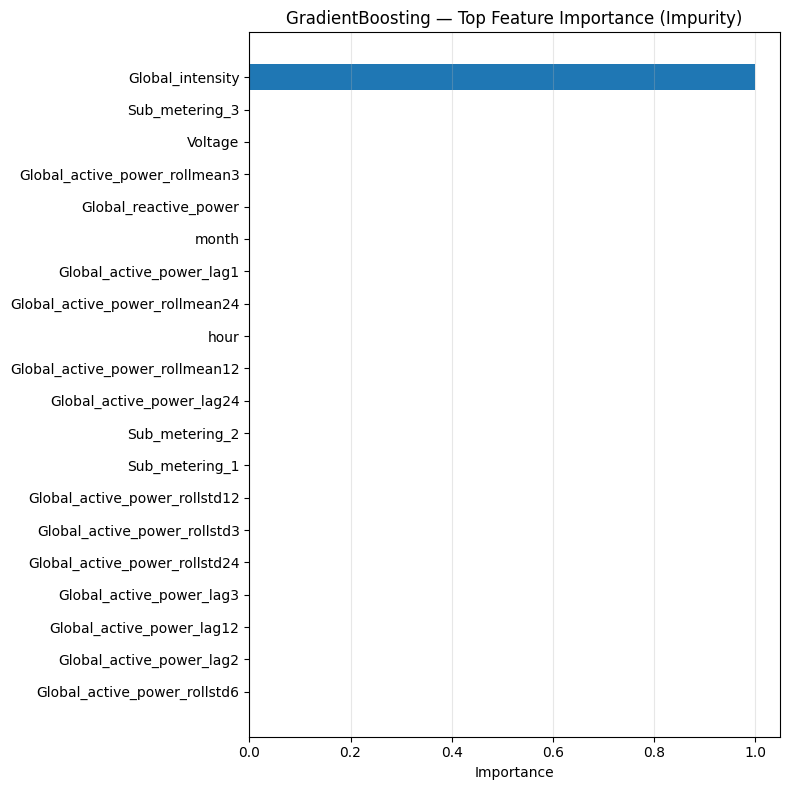

,RF_perm_importance(MSE),GB_perm_importance(MSE)
Global_active_power_lag1,-4.848841e-07,2.698399e-07
Global_active_power_lag12,-9.735626e-07,-8.819859e-08
Global_active_power_lag2,-7.638420e-07,8.985579e-08
Global_active_power_lag24,-1.062039e-06,-1.217157e-07
Global_active_power_lag3,-4.347334e-07,-1.530438e-07
Global_active_power_lag6,-5.257423e-08,8.674684e-09
Global_active_power_rollmean12,-7.234151e-07,1.173667e-06
Global_active_power_rollmean24,4.869880e-07,-4.050593e-07
Global_active_power_rollmean3,-2.528800e-06,3.949719e-06
Global_active_power_rollmean6,-4.116996e-07,2.083196e-08


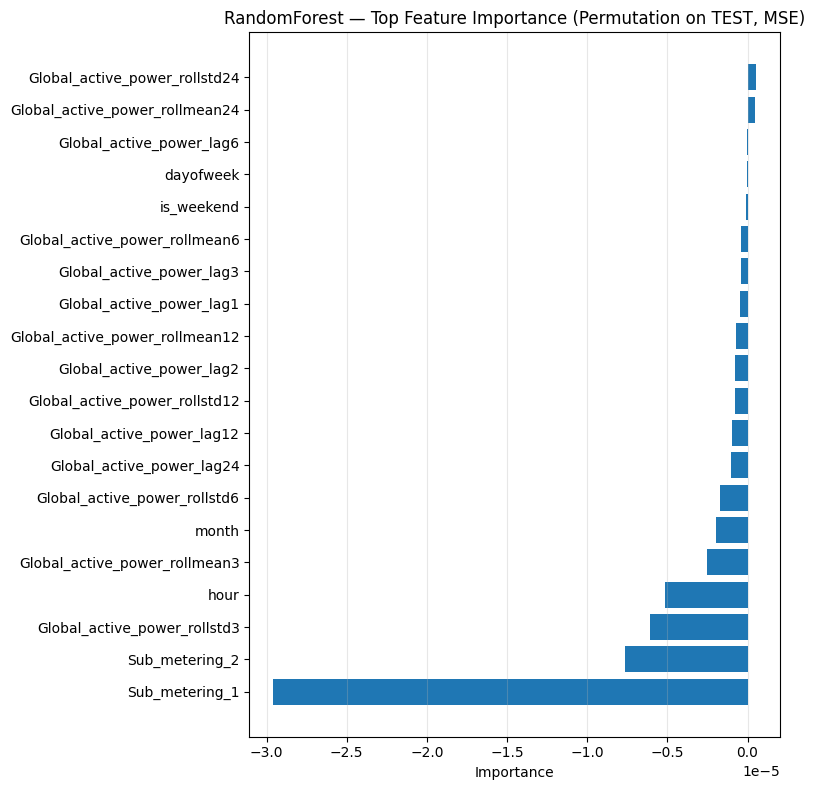

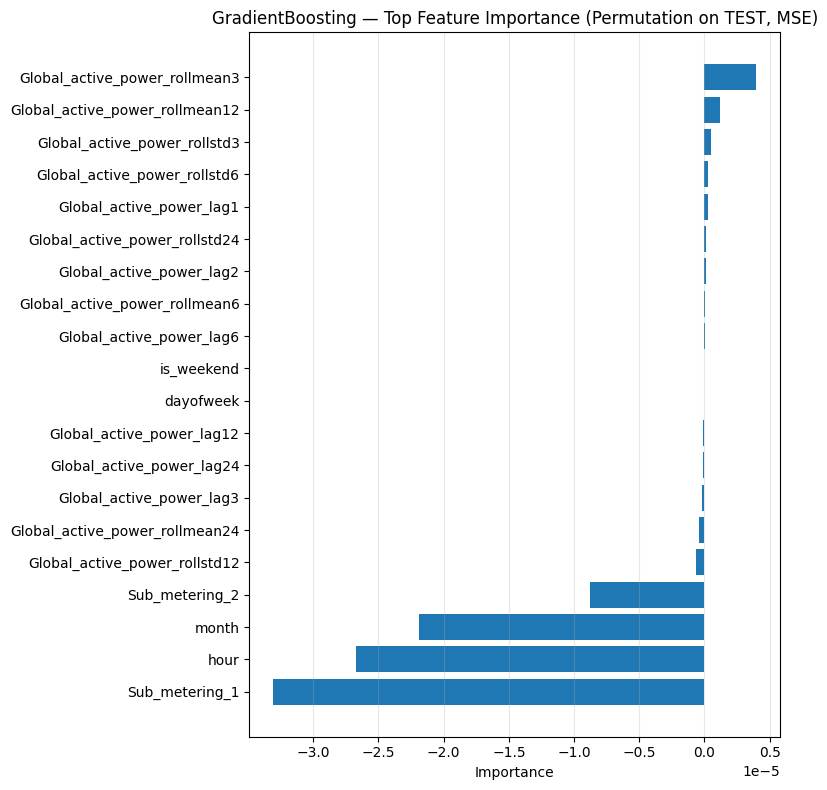

Saved:
/content/artifacts/feature_importance_impurity.csv
/content/artifacts/feature_importance_permutation_test.csv


In [ ]:
#12 — Feature Importance (Impurity & Permutation)
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, mean_squared_error

# ---------- Helper ----------
def plot_top_features(importances: pd.Series, title: str, top_n: int = 20):
    imp = importances.sort_values(ascending=True).tail(top_n)
    plt.figure(figsize=(8, max(5, int(top_n*0.4))))
    plt.barh(imp.index, imp.values)
    plt.title(title)
    plt.xlabel('Importance')
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

def to_series_importance(model, feature_names, normalize=False):
    imp = pd.Series(model.feature_importances_, index=feature_names)
    if normalize:
        total = imp.sum()
        if total > 0:
            imp = imp / total
    return imp.sort_values(ascending=False)

# ---------- 12A. Impurity-Based Importance ----------
rf_imp = to_series_importance(rf, X_train_tree.columns, normalize=True)
gb_imp = to_series_importance(gb, X_train_tree.columns, normalize=True)

display(pd.DataFrame({
    'RF_importance': rf_imp,
    'GB_importance': gb_imp
}).fillna(0).sort_values('RF_importance', ascending=False).head(20))

plot_top_features(rf_imp, 'RandomForest — Top Feature Importance (Impurity)', top_n=20)
plot_top_features(gb_imp, 'GradientBoosting — Top Feature Importance (Impurity)', top_n=20)

# Simpan ke CSV
fi_impurity_df = pd.DataFrame({
    'feature': X_train_tree.columns,
    'rf_importance': rf.feature_importances_,
    'gb_importance': gb.feature_importances_,
}).sort_values('rf_importance', ascending=False)
fi_impurity_df.to_csv(ARTIFACT_DIR / 'feature_importance_impurity.csv', index=False)

# ---------- 12B. Permutation Importance (di data TEST, TANPA paralel) ----------
def permutation_importance_mse(model, X, y, n_repeats=5, max_rows=None, rs=42):
    """
    max_rows: kalau None pakai seluruh test; kalau integer, hanya pakai baris terakhir sejumlah ini
              (mengurangi I/O & file memmap agar tidak kehabisan disk).
    """
    if max_rows is not None and len(X) > max_rows:
        X_eval = X.tail(max_rows)
        y_eval = y.tail(max_rows) if isinstance(y, pd.Series) else y[-max_rows:]
    else:
        X_eval, y_eval = X, y

    scorer = make_scorer(mean_squared_error, greater_is_better=False)
    r = permutation_importance(
        model, X_eval, y_eval,
        n_repeats=n_repeats,
        random_state=rs,
        scoring=scorer,
        n_jobs=1   # <<< penting: hindari paralel agar tidak membuat banyak memmap temp
    )
    # scoring = negative MSE → negasi supaya "lebih besar = lebih penting"
    imp = pd.Series(-r.importances_mean, index=X_eval.columns)
    imp_std = pd.Series(r.importances_std, index=X_eval.columns)
    return imp, imp_std

# Gunakan subset moderat agar hemat I/O (sesuaikan bila perlu)
subset_rows = min(5000, len(X_test_tree))  # mis. pakai max 5000 sampel terakhir
rf_perm_imp, rf_perm_std = permutation_importance_mse(rf, X_test_tree, y_test_tree, n_repeats=5, max_rows=subset_rows)
gb_perm_imp, gb_perm_std = permutation_importance_mse(gb, X_test_tree, y_test_tree, n_repeats=5, max_rows=subset_rows)

# Tampilkan Top 20 (Permutation)
display(pd.DataFrame({
    'RF_perm_importance(MSE)': rf_perm_imp.sort_values(ascending=False).head(20),
    'GB_perm_importance(MSE)': gb_perm_imp.sort_values(ascending=False).head(20)
}))

plot_top_features(rf_perm_imp, 'RandomForest — Top Feature Importance (Permutation on TEST, MSE)', top_n=20)
plot_top_features(gb_perm_imp, 'GradientBoosting — Top Feature Importance (Permutation on TEST, MSE)', top_n=20)

# Simpan ke CSV (urut berdasar RF; boleh diubah sesuai kebutuhan)
fi_perm_df = pd.DataFrame({
    'feature': X_test_tree.columns,
    'rf_perm_importance_mse': rf_perm_imp.reindex(X_test_tree.columns).values,
    'rf_perm_std': rf_perm_std.reindex(X_test_tree.columns).values,
    'gb_perm_importance_mse': gb_perm_imp.reindex(X_test_tree.columns).values,
    'gb_perm_std': gb_perm_std.reindex(X_test_tree.columns).values,
})
fi_perm_df.sort_values('rf_perm_importance_mse', ascending=False).to_csv(ARTIFACT_DIR / 'feature_importance_permutation_test.csv', index=False)

print("Saved:",
      (ARTIFACT_DIR / 'feature_importance_impurity.csv').resolve(),
      (ARTIFACT_DIR / 'feature_importance_permutation_test.csv').resolve(), sep="\n")


[Tuning] Pakai subset training: 7170/23902 sampel

Tuning RandomForest (n_iter=8, cv=3)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
RF best params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 141}
RF best CV score (MSE): -0.001265867752373225

RF — Ringkasan kandidat (MSE CV, lebih kecil lebih baik):
01. MSE=0.001300 ± 0.001192  | {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 186}
02. MSE=0.040962 ± 0.033806  | {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 162}
03. MSE=0.032289 ± 0.030935  | {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 196}
04. MSE=0.001319 ± 0.001224  | {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 167}
05. MSE=0.001300 ± 0.001190  | {'max_depth': 12, 'max

,Model,MAE,RMSE,R2
0,RF Default,0.013393,0.022120,0.999029
1,GB Default,0.012642,0.020607,0.999157
2,RF Tuned (subset tune),0.016567,0.024838,0.998775
3,GB Tuned (subset tune),0.014685,0.022611,0.998985


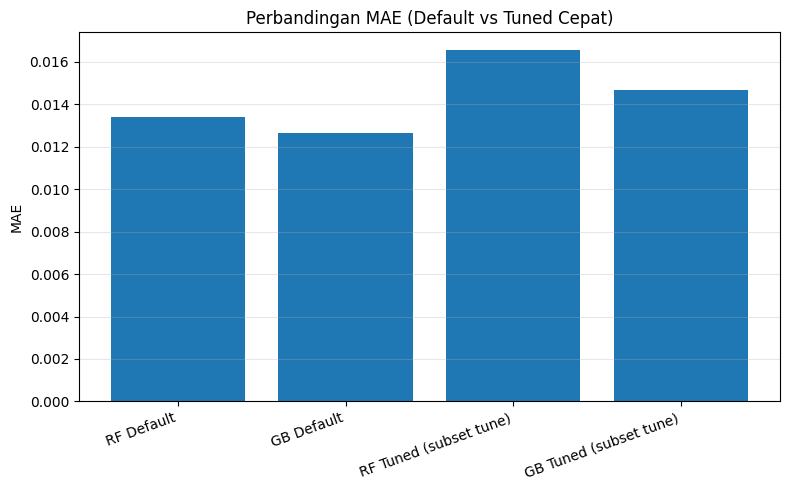

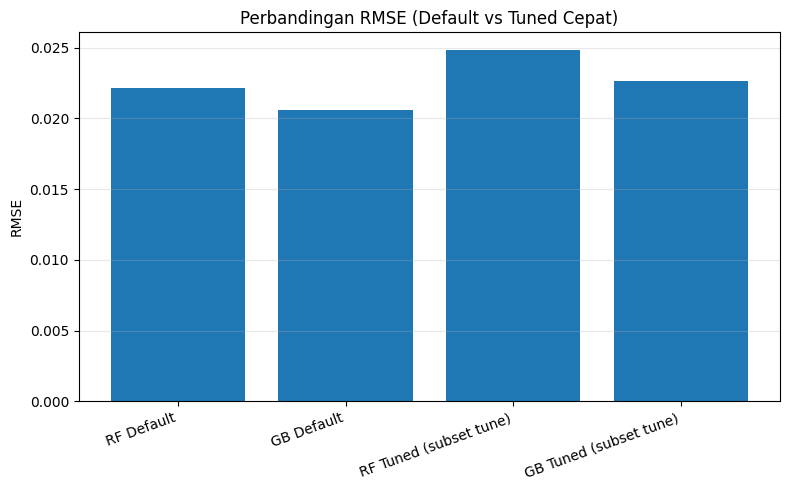

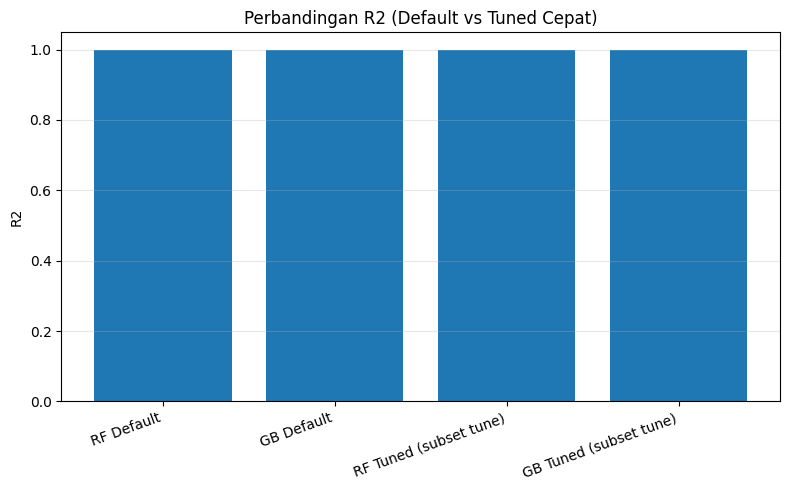

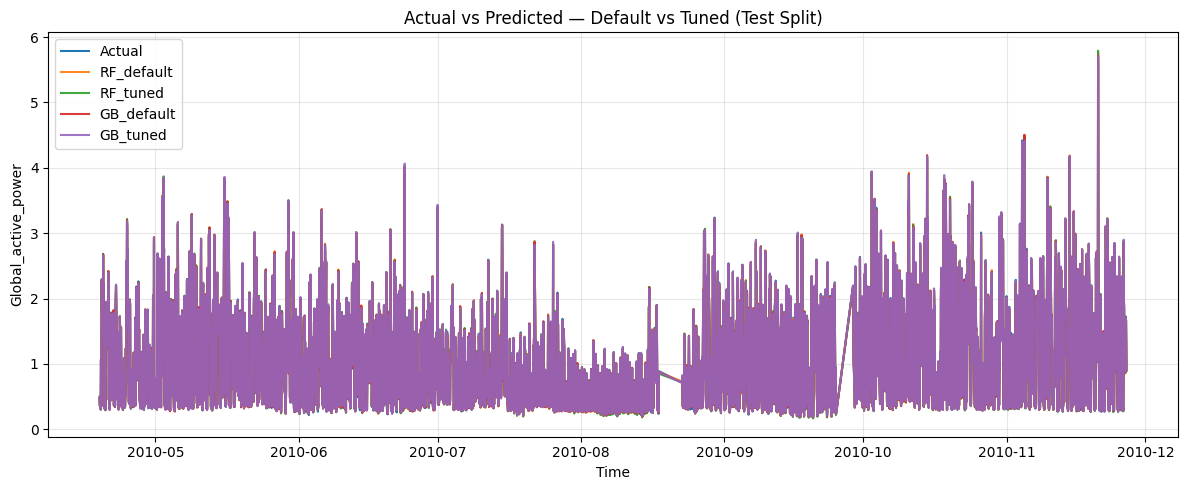

Saved tuned models & summary to: /content/artifacts


In [ ]:
#13 — Hyperparameter Tuning (Lebih Kompleks, RandomizedSearchCV)
#13 — Hyperparameter Tuning (CEPAT & INFORMATIF)

from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
import json, joblib

def print_cv_result(search, name):
    print(f"\n{name} — Ringkasan kandidat (MSE CV, lebih kecil lebih baik):")
    means = -search.cv_results_['mean_test_score']   # neg MSE -> MSE
    stds  = search.cv_results_['std_test_score']
    params = search.cv_results_['params']
    for i, p in enumerate(params):
        print(f"{i+1:02d}. MSE={means[i]:.6f} ± {stds[i]:.6f}  | {p}")

# ====== PARAM SPACE (dipersempit & masuk akal) ======
rf_param_dist_fast = {
    'n_estimators': randint(80, 200),
    'max_depth': [8, 12, None],
    'min_samples_split': randint(2, 6),
    'min_samples_leaf': randint(1, 4),
    'max_features': ['sqrt', None],
}

gb_param_dist_fast = {
    'n_estimators': randint(120, 360),
    'learning_rate': uniform(0.05, 0.15),
    'max_depth': randint(2, 6),
    'min_samples_split': randint(2, 6),
    'min_samples_leaf': randint(1, 4),
    'subsample': uniform(0.8, 0.2),
    'max_features': ['sqrt', None],
}

# ====== SUBSET TRAIN (hemat waktu) ======
use_subset = True
subset_ratio = 0.30
if use_subset:
    sub_n = max(2000, int(subset_ratio * len(X_train_tree)))  # minimal 2000 sampel biar stabil
    X_tune = X_train_tree.iloc[:sub_n]
    y_tune = y_train_tree.iloc[:sub_n]
    print(f"[Tuning] Pakai subset training: {len(X_tune)}/{len(X_train_tree)} sampel")
else:
    X_tune, y_tune = X_train_tree, y_train_tree
    print(f"[Tuning] Pakai full training: {len(X_tune)} sampel")

# ====== RandomizedSearchCV (lebih ringan) ======
print("\nTuning RandomForest (n_iter=8, cv=3)...")
rf_rand = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist_fast,
    n_iter=8,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_rand.fit(X_tune, y_tune)
print("RF best params:", rf_rand.best_params_)
print("RF best CV score (MSE):", rf_rand.best_score_)
print_cv_result(rf_rand, "RF")

print("\nTuning GradientBoosting (n_iter=8, cv=3)...")
gb_rand = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=gb_param_dist_fast,
    n_iter=8,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
gb_rand.fit(X_tune, y_tune)
print("GB best params:", gb_rand.best_params_)
print("GB best CV score (MSE):", gb_rand.best_score_)
print_cv_result(gb_rand, "GB")

# ====== Ambil best estimator & evaluasi di TEST (FULL) ======
rf_best = rf_rand.best_estimator_
gb_best = gb_rand.best_estimator_

rf_best_test_pred = pd.Series(rf_best.predict(X_test_tree), index=test_tree.index)
gb_best_test_pred = pd.Series(gb_best.predict(X_test_tree), index=test_tree.index)

rf_best_mae, rf_best_rmse, rf_best_r2 = regression_report(y_test_tree.values, rf_best_test_pred.values)
gb_best_mae, gb_best_rmse, gb_best_r2 = regression_report(y_test_tree.values, gb_best_test_pred.values)

print("\n=== Test Metrics (setelah tuning, evaluasi di TEST full) ===")
print(f"RF tuned: MAE={rf_best_mae:.4f}, RMSE={rf_best_rmse:.4f}, R²={rf_best_r2:.4f}")
print(f"GB tuned: MAE={gb_best_mae:.4f}, RMSE={gb_best_rmse:.4f}, R²={gb_best_r2:.4f}")

# ====== Tabel perbandingan (jika metrik default tersedia) ======
rows = []
if all(v in globals() for v in ['rf_mae','rf_rmse','rf_r2','gb_mae','gb_rmse','gb_r2']):
    rows.extend([
        {'Model':'RF Default','MAE':rf_mae,'RMSE':rf_rmse,'R2':rf_r2},
        {'Model':'GB Default','MAE':gb_mae,'RMSE':gb_rmse,'R2':gb_r2},
    ])
else:
    print("\n[Info] Metrik default tidak ditemukan — menampilkan hasil tuned saja.")

rows.extend([
    {'Model':'RF Tuned (subset tune)','MAE':rf_best_mae,'RMSE':rf_best_rmse,'R2':rf_best_r2},
    {'Model':'GB Tuned (subset tune)','MAE':gb_best_mae,'RMSE':gb_best_rmse,'R2':gb_best_r2},
])
compare_df = pd.DataFrame(rows)
display(compare_df)

# ====== Grafik bar ======
for metric in ['MAE','RMSE','R2']:
    plt.figure(figsize=(8,5))
    plt.bar(compare_df['Model'], compare_df[metric])
    plt.title(f'Perbandingan {metric} (Default vs Tuned Cepat)')
    plt.ylabel(metric); plt.xticks(rotation=20, ha='right')
    plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

# ====== (Opsional) Overlay time series jika tersedia variabel default & fungsi plot
can_overlay = ('plot_timeseries' in globals()
               and 'rf_test_pred' in globals()
               and 'gb_test_pred' in globals())
if can_overlay:
    plot_timeseries(
        test_tree[TARGET_COL],
        {
            'RF_default': rf_test_pred,
            'RF_tuned':   rf_best_test_pred,
            'GB_default': gb_test_pred,
            'GB_tuned':   gb_best_test_pred
        },
        title='Actual vs Predicted — Default vs Tuned (Test Split)',
        start=test_tree.index.min(), end=test_tree.index.max()
    )
else:
    print("\n[Info] Overlay time series dilewati (fungsi/variabel default belum ada).")

# ====== Simpan model & ringkasan ======
joblib.dump(rf_best, ARTIFACT_DIR / 'RF_TUNED_FAST.joblib')
joblib.dump(gb_best, ARTIFACT_DIR / 'GB_TUNED_FAST.joblib')

best_summary = {
    'rf_best_params': rf_rand.best_params_,
    'gb_best_params': gb_rand.best_params_,
    'rf_cv_rmse': float(((-rf_rand.best_score_)**0.5)),
    'gb_cv_rmse': float(((-gb_rand.best_score_)**0.5)),
    'rf_test': {'MAE': float(rf_best_mae), 'RMSE': float(rf_best_rmse), 'R2': float(rf_best_r2)},
    'gb_test': {'MAE': float(gb_best_mae), 'RMSE': float(gb_best_rmse), 'R2': float(gb_best_r2)},
    'tuning_subset_ratio': subset_ratio if use_subset else 1.0,
    'n_iter': 8, 'cv': 3
}
with open(ARTIFACT_DIR / 'tuning_best_summary_fast.json', 'w') as f:
    json.dump(best_summary, f, indent=2)

print("Saved tuned models & summary to:", ARTIFACT_DIR.resolve())




=== Test Metrics Model Terbaik (setelah tuning) ===
RandomForest tuned: MAE=0.0166, RMSE=0.0248, R²=0.9988
GradientBoosting tuned: MAE=0.0147, RMSE=0.0226, R²=0.9990


,Model,MAE,RMSE,R2
0,RF Default,0.013393,0.022120,0.999029
1,RF Tuned,0.016567,0.024838,0.998775
2,GB Default,0.012642,0.020607,0.999157
3,GB Tuned,0.014685,0.022611,0.998985


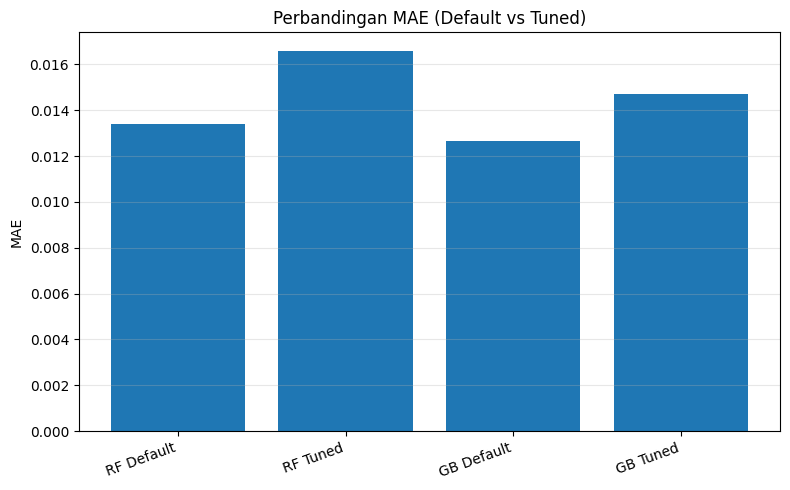

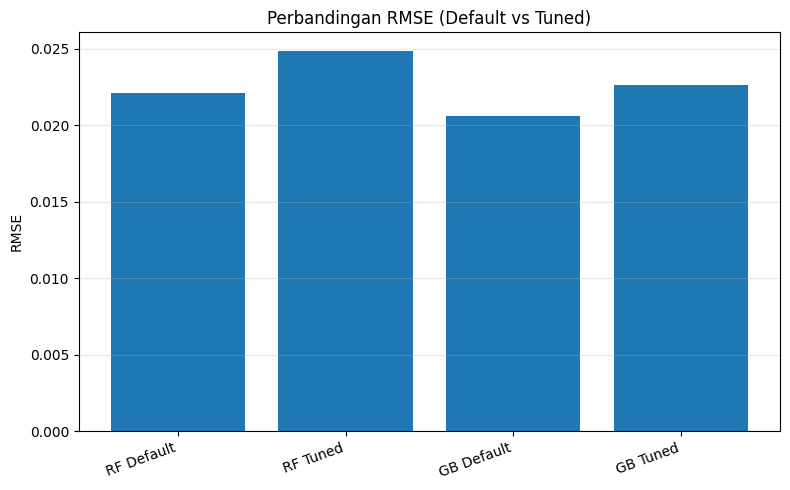

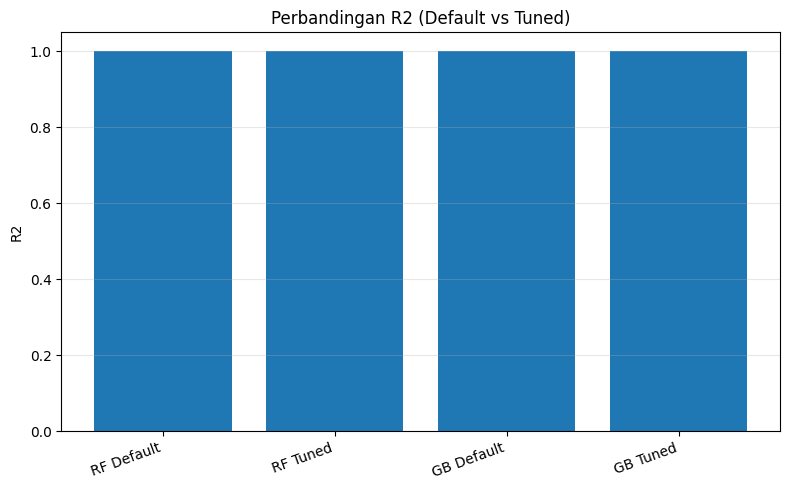

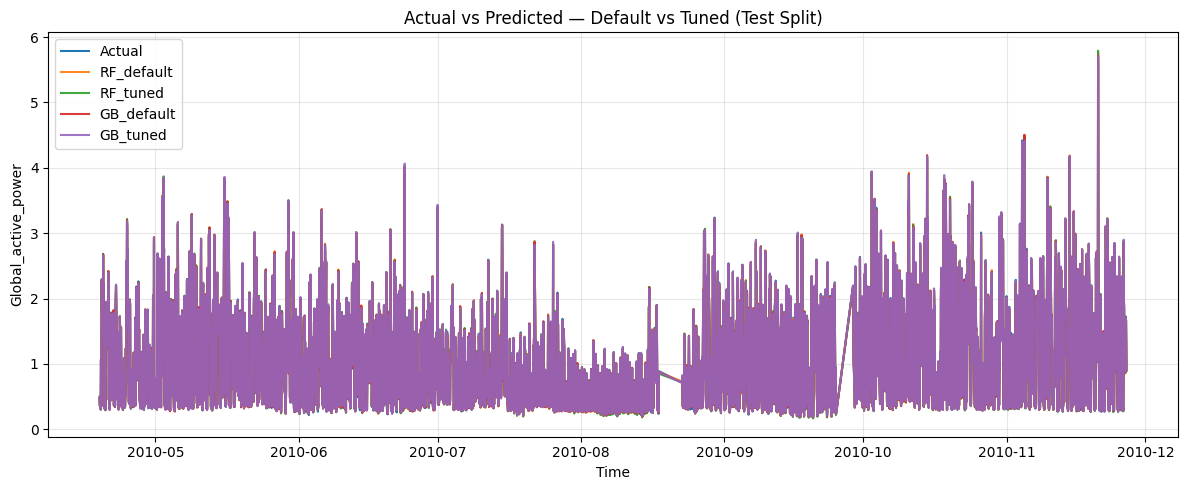

In [ ]:
# ==== Evaluasi ulang di TEST set (Default vs Tuned) ====
# Pred default (sudah ada dari Sel #6): rf_test_pred, gb_test_pred
rf_best = rf_rand.best_estimator_
gb_best = gb_rand.best_estimator_

rf_best_test_pred = pd.Series(rf_best.predict(X_test_tree), index=test_tree.index)
gb_best_test_pred = pd.Series(gb_best.predict(X_test_tree), index=test_tree.index)

rf_best_mae, rf_best_rmse, rf_best_r2 = regression_report(y_test_tree.values, rf_best_test_pred.values)
gb_best_mae, gb_best_rmse, gb_best_r2 = regression_report(y_test_tree.values, gb_best_test_pred.values)

print("\n=== Test Metrics Model Terbaik (setelah tuning) ===")
print("RandomForest tuned: MAE=%.4f, RMSE=%.4f, R²=%.4f" % (rf_best_mae, rf_best_rmse, rf_best_r2))
print("GradientBoosting tuned: MAE=%.4f, RMSE=%.4f, R²=%.4f" % (gb_best_mae, gb_best_rmse, gb_best_r2))

# ==== Bar chart perbandingan Default vs Tuned ====
compare_df = pd.DataFrame([
    {'Model': 'RF Default', 'MAE': rf_mae, 'RMSE': rf_rmse, 'R2': rf_r2},
    {'Model': 'RF Tuned',   'MAE': rf_best_mae, 'RMSE': rf_best_rmse, 'R2': rf_best_r2},
    {'Model': 'GB Default', 'MAE': gb_mae, 'RMSE': gb_rmse, 'R2': gb_r2},
    {'Model': 'GB Tuned',   'MAE': gb_best_mae, 'RMSE': gb_best_rmse, 'R2': gb_best_r2},
])
display(compare_df)

for metric in ['MAE','RMSE','R2']:
    plt.figure(figsize=(8,5))
    plt.bar(compare_df['Model'], compare_df[metric])
    plt.title(f'Perbandingan {metric} (Default vs Tuned)')
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==== (Opsional) Overlay time series test: Tuned vs Default ====
plot_timeseries(
    test_tree[TARGET_COL],
    {
        'RF_default': rf_test_pred,
        'RF_tuned':   rf_best_test_pred,
        'GB_default': gb_test_pred,
        'GB_tuned':   gb_best_test_pred
    },
    title='Actual vs Predicted — Default vs Tuned (Test Split)',
    start=test_tree.index.min(), end=test_tree.index.max()
)


In [ ]:
joblib.dump(rf_best, ARTIFACT_DIR / 'random_forest_regressor_TUNED.joblib')
joblib.dump(gb_best, ARTIFACT_DIR / 'gradient_boosting_regressor_TUNED.joblib')
print("Tuned models saved in:", ARTIFACT_DIR.resolve())


Tuned models saved in: /content/artifacts


Menyiapkan data multi-output forecasting (stride=2)...
Shapes: (11943, 24) (11943, 24) (2559, 24) (2559, 24)
Training MultiOutput ExtraTrees...
Multi-Output ExtraTrees (24h at once, stride=2):
Overall  MAE=0.4919, RMSE=0.6167


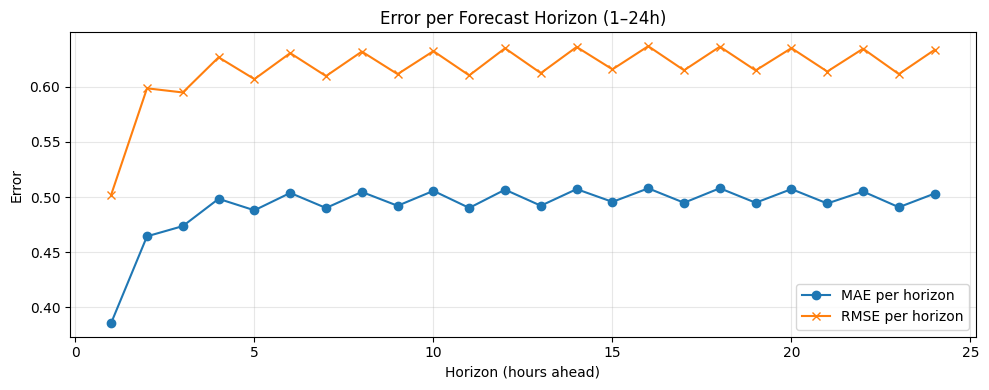

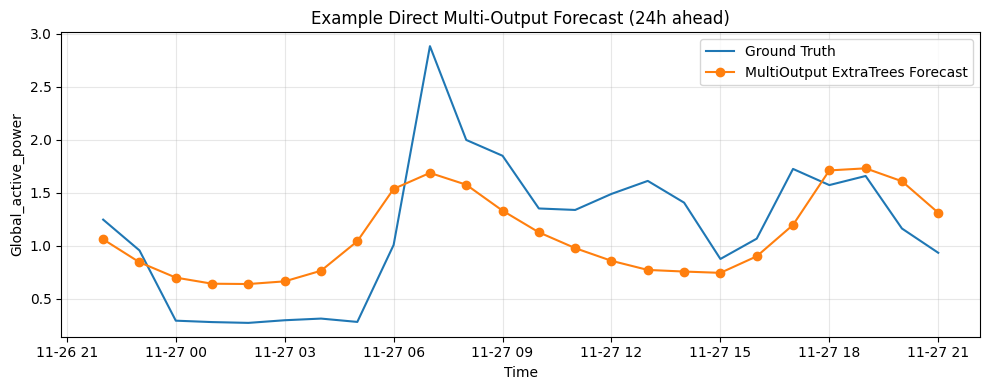

In [ ]:
#14 — Multi-step Forecast 24 Jam (Tree-based & LSTM)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import ExtraTreesRegressor

# ===== Helper dataset multi-output dengan stride =====
def make_multioutput_dataset(series: pd.Series, window: int, horizon: int, stride: int = 2):
    """
    Membuat supervised dataset multi-output.
    Input X: window (lag N jam terakhir).
    Output y: horizon (H jam ke depan).
    stride: langkah maju (default=2 untuk kurangi ukuran dataset).
    """
    X, y = [], []
    vals = series.values
    for i in range(window, len(vals) - horizon + 1, stride):
        X.append(vals[i-window:i])
        y.append(vals[i:i+horizon])
    return np.array(X), np.array(y)

print("Menyiapkan data multi-output forecasting (stride=2)...")
target_series = df_hour[TARGET_COL].dropna()

# Scaling target
scaler_multi = StandardScaler()
target_scaled = scaler_multi.fit_transform(target_series.values.reshape(-1,1)).ravel()
target_scaled_series = pd.Series(target_scaled, index=target_series.index)

# Dataset: window 24 jam -> prediksi 24 jam
X_multi, y_multi = make_multioutput_dataset(target_scaled_series, window=LSTM_WINDOW, horizon=24, stride=2)

# Split train/val/test sesuai rasio
n = len(X_multi)
n_test = int(n * TEST_SIZE_RATIO)
n_val  = int(n * VAL_SIZE_RATIO)
n_train = n - n_test - n_val

X_train_m, X_val_m, X_test_m = X_multi[:n_train], X_multi[n_train:n_train+n_val], X_multi[n_train+n_val:]
y_train_m, y_val_m, y_test_m = y_multi[:n_train], y_multi[n_train:n_train+n_val], y_multi[n_train+n_val:]

print("Shapes:", X_train_m.shape, y_train_m.shape, X_test_m.shape, y_test_m.shape)

# ===== Train Multi-Output ExtraTrees =====
print("Training MultiOutput ExtraTrees...")
base_et = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=12,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
mo_et = MultiOutputRegressor(base_et, n_jobs=-1)
mo_et.fit(X_train_m, y_train_m)

# Prediksi test
y_pred_m = mo_et.predict(X_test_m)

# Inverse transform
y_test_inv = scaler_multi.inverse_transform(y_test_m.reshape(-1,1)).reshape(y_test_m.shape)
y_pred_inv = scaler_multi.inverse_transform(y_pred_m.reshape(-1,1)).reshape(y_pred_m.shape)

# ===== Evaluasi multi-step langsung =====
mae_all = mean_absolute_error(y_test_inv.ravel(), y_pred_inv.ravel())
rmse_all = math.sqrt(np.mean((y_test_inv - y_pred_inv)**2))

print(f"Multi-Output ExtraTrees (24h at once, stride=2):")
print(f"Overall  MAE={mae_all:.4f}, RMSE={rmse_all:.4f}")

# Error per horizon
mae_horizons, rmse_horizons = [], []
for h in range(24):
    mae_h = mean_absolute_error(y_test_inv[:,h], y_pred_inv[:,h])
    rmse_h = math.sqrt(np.mean((y_test_inv[:,h] - y_pred_inv[:,h])**2))
    mae_horizons.append(mae_h)
    rmse_horizons.append(rmse_h)

plt.figure(figsize=(10,4))
plt.plot(range(1,25), mae_horizons, marker='o', label='MAE per horizon')
plt.plot(range(1,25), rmse_horizons, marker='x', label='RMSE per horizon')
plt.title('Error per Forecast Horizon (1–24h)')
plt.xlabel('Horizon (hours ahead)')
plt.ylabel('Error')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ===== Visualisasi contoh forecast batch terakhir =====
idx_start = -1  # ambil contoh batch terakhir
true_seq = y_test_inv[idx_start]
pred_seq = y_pred_inv[idx_start]

start_time = target_series.index[-len(y_test_m):][idx_start] + pd.Timedelta(hours=1)
# FIX: gunakan 'h' (huruf kecil) agar tidak muncul FutureWarning
horizon_index = pd.date_range(start=start_time, periods=24, freq='h')

plt.figure(figsize=(10,4))
plt.plot(horizon_index, true_seq, label='Ground Truth')
plt.plot(horizon_index, pred_seq, marker='o', label='MultiOutput ExtraTrees Forecast')
plt.title('Example Direct Multi-Output Forecast (24h ahead)')
plt.xlabel('Time'); plt.ylabel(TARGET_COL)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


Total test windows: 2559
Dipakai subset: 300


Predicting LSTM (subset):   0%|          | 0/300 [00:00<?, ?it/s]

,Model,MAE,RMSE
0,"LSTM (recursive 24h, subset=300)",0.503414,0.703162
1,"ExtraTrees (multi-output, full)",0.491895,0.616688


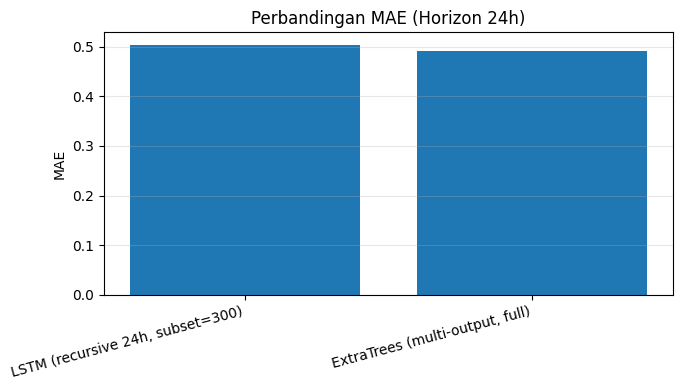

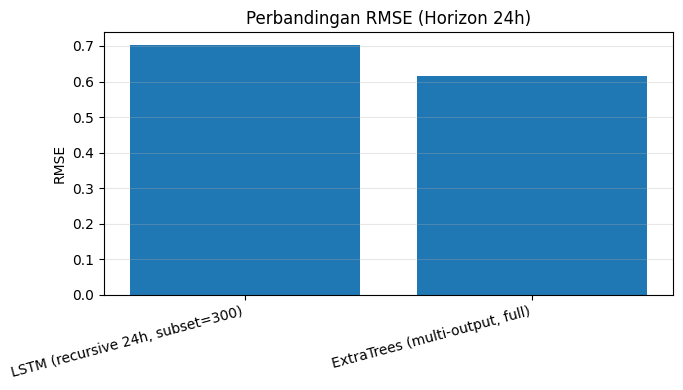

Saved: /content/artifacts/summary_lstm_vs_extratrees_24h_fast.csv


In [ ]:
# ===== Sel #15 — Ringkasan cepat: LSTM (recursive) vs ExtraTrees Multi-Output =====

from tqdm.auto import tqdm

STRIDE  = 2
HORIZON = 24
WINDOW  = LSTM_WINDOW
SUBSET  = 300   # ambil hanya 300 window test terakhir (lebih cepat)

def make_windows(vals, window, horizon, stride=2):
    X, y = [], []
    for i in range(window, len(vals) - horizon + 1, stride):
        X.append(vals[i-window:i])
        y.append(vals[i:i+horizon])
    return np.array(X), np.array(y)

# --- Build ulang windows
target_series_full = df_hour[TARGET_COL].dropna()

# a) Ground truth
X_all_raw, y_all_raw = make_windows(target_series_full.values, WINDOW, HORIZON, stride=STRIDE)

# b) Input untuk LSTM
scaled_for_lstm = scaler_y.transform(
    pd.DataFrame(target_series_full.values, columns=[TARGET_COL])
).ravel()
X_all_scaled_lstm, _ = make_windows(scaled_for_lstm, WINDOW, HORIZON, stride=STRIDE)

# c) Split konsisten
n = len(X_all_raw)
n_test = int(n * TEST_SIZE_RATIO)
n_val  = int(n * VAL_SIZE_RATIO)
n_train = n - n_test - n_val

X_test_win_scaled = X_all_scaled_lstm[n_train+n_val:]
y_test_win_raw    = y_all_raw[n_train+n_val:]

# --- Ambil subset terakhir
X_test_sub = X_test_win_scaled[-SUBSET:]
y_test_sub = y_test_win_raw[-SUBSET:]

print("Total test windows:", X_test_win_scaled.shape[0])
print("Dipakai subset:", X_test_sub.shape[0])

# --- Prediksi LSTM recursive
def lstm_recursive_over_windows(X_windows_scaled, model, scaler, horizon):
    preds = []
    for w in tqdm(range(X_windows_scaled.shape[0]), desc="Predicting LSTM (subset)"):
        seq = X_windows_scaled[w].copy()
        out = []
        for h in range(horizon):
            x_in = seq.reshape(1, WINDOW, 1)
            yhat_s = model.predict(x_in, verbose=0).ravel()[0]
            yhat = scaler.inverse_transform(
                pd.DataFrame([[yhat_s]], columns=[TARGET_COL])
            )[0, 0]
            out.append(yhat)
            seq = np.concatenate([seq[1:], [yhat_s]])
        preds.append(out)
    return np.array(preds)

y_pred_lstm_sub = lstm_recursive_over_windows(X_test_sub, model, scaler_y, HORIZON)

# --- Evaluasi (butuh ExtraTrees hasil Sel #14)
if 'y_test_inv' not in globals() or 'y_pred_inv' not in globals():
    raise RuntimeError("Jalankan Sel #14 (ExtraTrees) dulu agar y_test_inv & y_pred_inv tersedia.")

# LSTM (subset)
mae_lstm_all  = mean_absolute_error(y_test_sub.ravel(), y_pred_lstm_sub.ravel())
rmse_lstm_all = float(np.sqrt(np.mean((y_test_sub - y_pred_lstm_sub)**2)))

# ExtraTrees (full test, sama dengan Sel #14)
mae_et_all    = mean_absolute_error(y_test_inv.ravel(), y_pred_inv.ravel())
rmse_et_all   = float(np.sqrt(np.mean((y_test_inv - y_pred_inv)**2)))

summary_df = pd.DataFrame([
    {'Model': f'LSTM (recursive 24h, subset={SUBSET})', 'MAE': mae_lstm_all, 'RMSE': rmse_lstm_all},
    {'Model': 'ExtraTrees (multi-output, full)',        'MAE': mae_et_all,   'RMSE': rmse_et_all},
])
display(summary_df)

# Grafik ringkasan
plt.figure(figsize=(7,4))
plt.bar(summary_df['Model'], summary_df['MAE'])
plt.ylabel('MAE'); plt.title('Perbandingan MAE (Horizon 24h)')
plt.xticks(rotation=15, ha='right'); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.bar(summary_df['Model'], summary_df['RMSE'])
plt.ylabel('RMSE'); plt.title('Perbandingan RMSE (Horizon 24h)')
plt.xticks(rotation=15, ha='right'); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

# Simpan ringkasan
out_path = ARTIFACT_DIR / 'summary_lstm_vs_extratrees_24h_fast.csv'
summary_df.to_csv(out_path, index=False)
print("Saved:", out_path.resolve())


In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip --version

pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


In [ ]:
!pip freeze > requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.4
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.51.3.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.30.0.54.34
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.38.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
c

In [ ]:
import shutil
from google.colab import files
import os

# Nama folder yang benar sesuai gambar/sistem
nama_folder = 'artifacts'
nama_zip = 'download_artifacts' # Nama file hasil download

# Mengecek apakah folder benar-benar ada
if os.path.exists(nama_folder):
    print(f"Sedang mengompresi folder '{nama_folder}' menjadi .zip...")
    # Mengubah isi folder menjadi file .zip
    shutil.make_archive(nama_zip, 'zip', nama_folder)

    print("Selesai dikompresi! Mulai mengunduh file ke komputer Anda...")
    # Memunculkan pop-up download
    files.download(f"{nama_zip}.zip")
else:
    print(f"Error: Folder '{nama_folder}' tidak ditemukan. Pastikan Anda berada di direktori yang tepat.")

Sedang mengompresi folder 'artifacts' menjadi .zip...
Selesai dikompresi! Mulai mengunduh file ke komputer Anda...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>